In [51]:
# Task 1: Data Loading and Exploration
# 1. 安装 PySpark
!pip install pyspark

# 2. 导入必需的库 Import the required libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, isnull, count, explode, split, lower, regexp_replace, when
import pandas as pd # 方便在 Colab 中绘图
import matplotlib.pyplot as plt
import seaborn as sns

# 3. 创建 Spark Session
# 这是所有 PySpark 功能的入口点
spark = SparkSession.builder.appName("TextAnalysis").getOrCreate()
print("Spark Session Created successfully！")


Spark Session Created successfully！


In [52]:
data_path = "twitter_validation.csv"

columns = ["TweetID", "Entity", "Sentiment", "Tweet content"]

df = (
    spark.read
    .option("header", "false")
    .option("multiLine", "true")
    .option("quote", '"')
    .option("escape", '"')
    .option("encoding", "UTF-8")
    .csv(data_path)
    .toDF(*columns)
)

print("Dataset loaded successfully.")
print(f"Total records: {df.count()}")
df.printSchema()

Dataset loaded successfully.
Total records: 1000
root
 |-- TweetID: string (nullable = true)
 |-- Entity: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- Tweet content: string (nullable = true)



In [53]:
# Display Schema
print("--- DataFrame Schema ---")
df.printSchema()

--- DataFrame Schema ---
root
 |-- TweetID: string (nullable = true)
 |-- Entity: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- Tweet content: string (nullable = true)



In [54]:
print("\nAfter the merger DataFrame 结构:")
df.printSchema()
print("\nThe first 5 records after merging (Check if the Tweet_content is correct.):")
df.show(5, truncate=False)


After the merger DataFrame 结构:
root
 |-- TweetID: string (nullable = true)
 |-- Entity: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- Tweet content: string (nullable = true)


The first 5 records after merging (Check if the Tweet_content is correct.):
+-------+---------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|TweetID|Entity   |Sentiment |Tweet content                                                                                                                                                                                                                                      |
+-------+---------+----------+----------------------------------------------------------------------------------------------------------------------------------------------

In [55]:
# Record Count
record_count = df.count()
print(f"\n--- Total number of records ---")
print(f"The dataset contains **{record_count}** records")


--- Total number of records ---
The dataset contains **1000** records


In [56]:
print("\n--- Sample rows (first 5 rows) ---")
df.show(5, truncate=50) # 展示 5 行，将长字符串在 50 个字符后截断


--- Sample rows (first 5 rows) ---
+-------+---------+----------+--------------------------------------------------+
|TweetID|   Entity| Sentiment|                                     Tweet content|
+-------+---------+----------+--------------------------------------------------+
|   3364| Facebook|Irrelevant|I mentioned on Facebook that I was struggling f...|
|    352|   Amazon|   Neutral|BBC News - Amazon boss Jeff Bezos rejects claim...|
|   8312|Microsoft|  Negative|@Microsoft Why do I pay for WORD when it functi...|
|   4371|    CS-GO|  Negative|CSGO matchmaking is so full of closet hacking, ...|
|   4433|   Google|   Neutral|Now the President is slapping Americans in the ...|
+-------+---------+----------+--------------------------------------------------+
only showing top 5 rows


In [57]:
# Initial Text Exploratory Data Analysis (EDA)
# Missing Value Count
print("--- Missing value count for each column ---")
# 使用 when/isnull/count 组合来计算每一列的缺失值（包括 null 和空字符串或字符串 'null'）
df.select([count(when(isnull(c) | (col(c) == "") | (col(c).cast("string") == "null"), c)).alias(c) for c in df.columns]).show()

--- Missing value count for each column ---
+-------+------+---------+-------------+
|TweetID|Entity|Sentiment|Tweet content|
+-------+------+---------+-------------+
|      0|     0|        0|            0|
+-------+------+---------+-------------+




--- Text length descriptive statistics ---
+-------+-----------------+
|summary|      text_length|
+-------+-----------------+
|  count|             1000|
|   mean|          131.849|
| stddev|81.92542935484059|
|    min|                3|
|    max|              340|
+-------+-----------------+



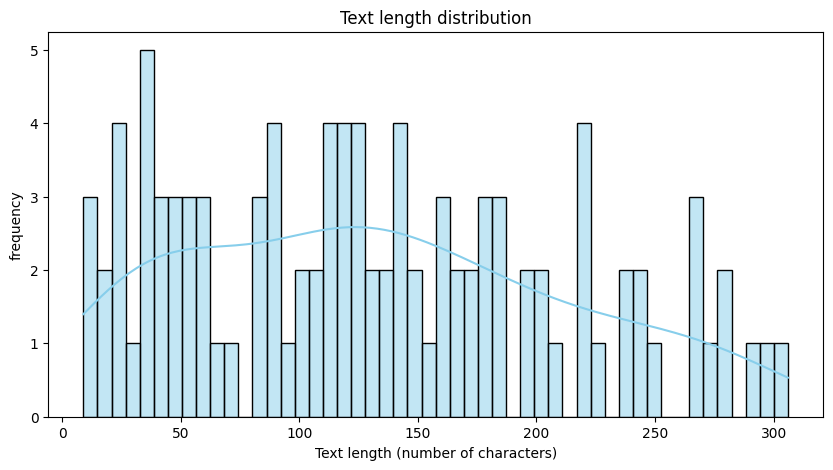

In [58]:
# Text Length Calculation
# 1. 创建新列 'text_length'
df = df.withColumn('text_length', length(col('Tweet content')))

# 2. 显示文本长度的描述性统计信息
print("\n--- Text length descriptive statistics ---")
df.select(col('text_length')).describe().show()

# 3. 绘制文本长度分布图（为方便绘图，使用 Pandas）
# 对数据进行采样，以便在大型数据集上更快地绘图
text_length_data = df.select('text_length').sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 5))
sns.histplot(text_length_data['text_length'], bins=50, kde=True, color='skyblue')
plt.title('Text length distribution')
plt.xlabel('Text length (number of characters)')
plt.ylabel('frequency')
plt.show()

In [59]:
# Before counting, need to perform basic text cleanup (lowercase, remove punctuation).

# 1. 基本清理：转换为小写并删除非单词字符
cleaned_df = df.withColumn('cleaned_text', lower(col('Tweet content')))
# 替换非字母和非空格字符为空
cleaned_df = cleaned_df.withColumn('cleaned_text', regexp_replace(col('cleaned_text'), r'[^a-z\s]', ''))

# 2. 将文本标记化为单个词语
words_df = cleaned_df.select(explode(split(col('cleaned_text'), r'\s+')).alias('word'))

# 3. 过滤掉拆分/清理后可能产生的空字符串
words_df = words_df.filter(col('word') != "")


--- Top 20 最常出现的词 ---
    word  count
0    the    628
1     to    432
2    and    395
3      a    394
4      i    372
5     of    291
6     is    285
7    for    237
8   this    231
9     in    212
10    it    187
11    on    177
12   you    172
13    my    157
14  with    147
15  that    135
16    me    112
17  game    107
18    so    105
19  have     89


/tmp/ipykernel_1369/1560693773.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top_words_pd, palette='viridis')


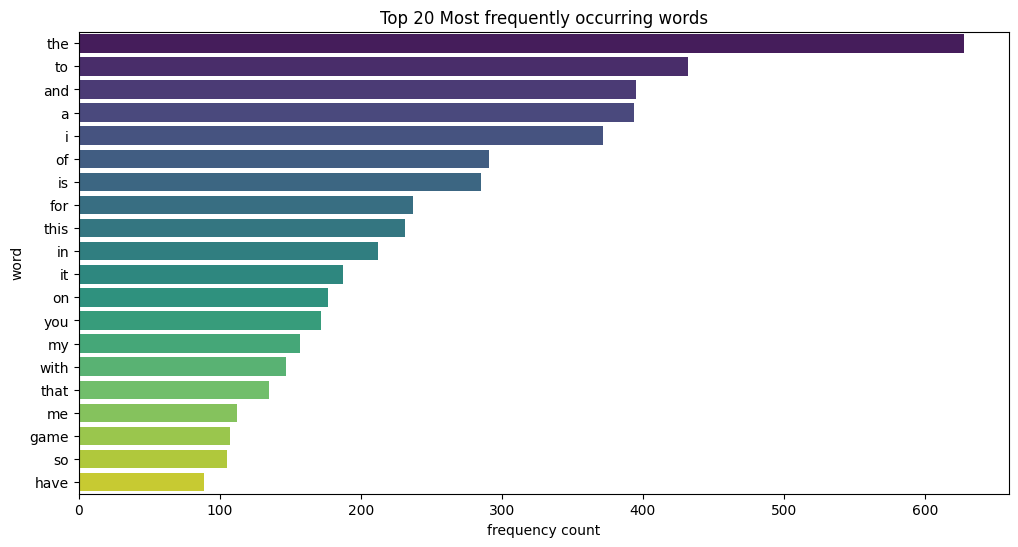

In [60]:
#Calculate and Display Top 20 Frequent Words

print("\n--- Top 20 最常出现的词 ---")
word_counts = words_df.groupBy('word').count().orderBy(col('count').desc())

# 获取前 20 个词用于展示和绘图
top_words_pd = word_counts.limit(20).toPandas()
print(top_words_pd)

# 绘制前 20 个词
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='word', data=top_words_pd, palette='viridis')
plt.title('Top 20 Most frequently occurring words')
plt.xlabel('frequency count')
plt.ylabel('word')
plt.show()


--- Top 20 最常出现的标签（Hashtags） ---
                    token  count
0            #ApexLegends     16
1        #RainbowSixSiege     11
2                 #twitch     11
3            #Hearthstone     11
4            #XboxSeriesX     10
5               #PS4share      9
6             #CallofDuty      8
7          #ModernWarfare      8
8                 #gaming      8
9              #XboxShare      8
10              #Fortnite      8
11       #LeagueOfLegends      7
12                   #PS5      7
13               #Warzone      6
14                  #Xbox      6
15         #Cyberpunk2077      6
16              #Warcraft      6
17          #PlayStation5      5
18  #GhostReconBreakpoint      5
19             #overwatch      5


/tmp/ipykernel_1369/2976354016.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='token', data=top_hashtags_pd, palette='magma')


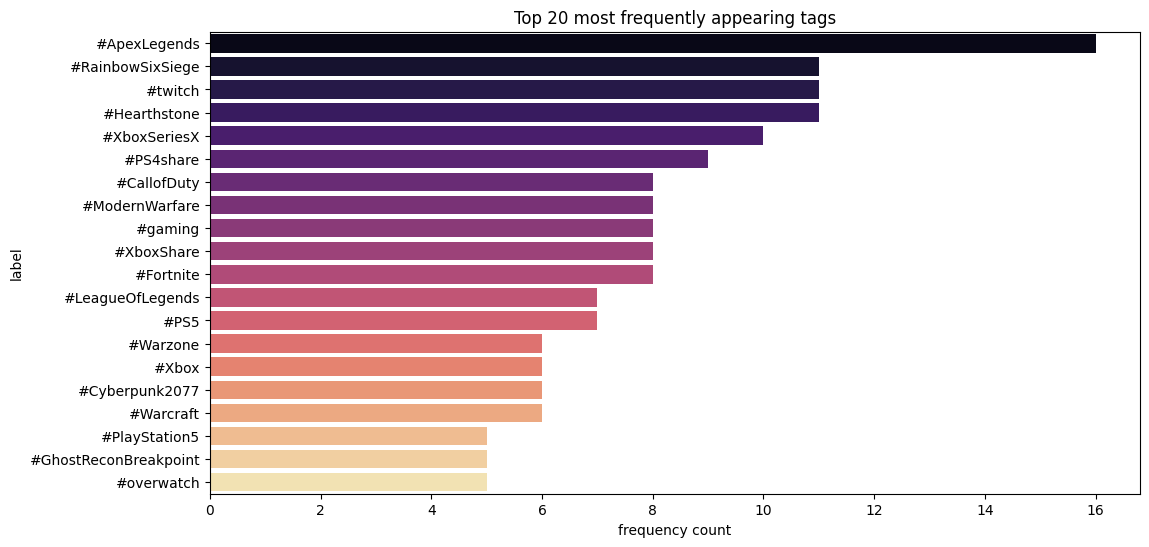

In [61]:
# Calculate and display the most frequently occurring hashtags.

print("\n--- Top 20 最常出现的标签（Hashtags） ---")

# 1. 提取潜在的标签（以 # 开头的词）
hashtags_df = df.select(explode(split(col('Tweet content'), r'\s+')).alias('token'))
hashtags_df = hashtags_df.filter(col('token').like('#%'))

# 2. 计数并排序标签
hashtag_counts = hashtags_df.groupBy('token').count().orderBy(col('count').desc())

# 获取前 20 个标签
top_hashtags_pd = hashtag_counts.limit(20).toPandas()
print(top_hashtags_pd)

# 绘制前 20 个标签
plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='token', data=top_hashtags_pd, palette='magma')
plt.title('Top 20 most frequently appearing tags')
plt.xlabel('frequency count')
plt.ylabel('label')
plt.show()

In [62]:
# task2 Text Cleaning and Preprocessing

# Import required modules
from pyspark.sql.functions import col, lower, regexp_replace, explode, split, array_remove, size, count, lit, when, udf
from pyspark.ml.feature import StopWordsRemover, Tokenizer
from pyspark.sql.types import ArrayType, StringType
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# 确保 NLTK 数据已下载
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [63]:
# Handling null values ​​and noise
initial_count = df.count()
# 1. 删除包含空文本内容的行
df_clean = df.filter(col("Tweet content").isNotNull() & (col("Tweet content") != ""))

# 2. 如果存在 Task 1 中发现的 _c4 噪声列，现在删除它
if "_c4" in df_clean.columns:
    df_clean = df_clean.drop("_c4")

final_count = df_clean.count()
print(f"Original number of records: {initial_count}, Number of records after clearing null values: {final_count}")

Original number of records: 1000, Number of records after clearing null values: 1000


In [64]:
# Handle duplicates
df_clean = df_clean.dropDuplicates(['Tweet content'])
print(f"Number of records after removing duplicates: {df_clean.count()}")

Number of records after removing duplicates: 999


In [65]:
# Core Text Preprocessing Pipeline

# Convert all text to lowercase
#1.小写转换 (Lowercasing)将所有文本转换为小写。这是为了确保“Apple”和“apple”被视为同一个词。这极大地减少了词汇量并标准化了数据。
df_clean = df_clean.withColumn("text_lower", lower(col("Tweet content")))

In [66]:
# Remove all punctuation marks, numbers, and special characters.

# 2.标点符号和数字移除 (Punctuation and Number Removal)移除所有非字母和非空格字符
df_clean = df_clean.withColumn("text_no_punct", regexp_replace(col("text_lower"), "[^a-z\\s]", " "))

In [67]:
# Break the text down into individual tokens.

#3.分词 (Tokenization)将文本拆分成单个词语（Token），这是所有后续词汇处理的基础
tokenizer = Tokenizer(inputCol="text_no_punct", outputCol="text_tokens")

# 如果 'text_tokens' 列已存在（例如，由于重复运行），则先删除它。
# 这可以防止在重新执行时出现 "Output column already exists" 错误。
if "text_tokens" in df_clean.columns:
    df_clean = df_clean.drop("text_tokens")

df_clean = tokenizer.transform(df_clean)

# 额外步骤：移除分词后产生的空字符串/单个字母（如'a','i'等）
df_clean = df_clean.withColumn("text_tokens", array_remove(col("text_tokens"), ""))

In [68]:
# Remove common words that do not contribute much to the meaning of the text.

#4.停用词移除 (Stopword Removal)移除常见的、但对文本意义贡献不大的词语，如 "the", "a", "is", "of" 等。这能降低维度，提高分析效率和相关词的权重。
# a. 获取 NLTK 英文停用词列表，并确保其为小写
stop_words = stopwords.words('english')

# b.创建 PySpark StopWordsRemover 转换器
remover = StopWordsRemover(inputCol="text_tokens", outputCol="text_no_stop", stopWords=stop_words)

# 如果 'text_no_stop' 列已存在（例如，由于重复运行），则先删除它。
# 这可以防止在重新执行时出现 "Output column already exists" 错误。
if "text_no_stop" in df_clean.columns:
    df_clean = df_clean.drop("text_no_stop")

# c. 执行移除
df_clean = remover.transform(df_clean)

In [69]:
# Reduce words to their basic or dictionary form (lemma).

#5.词形还原 (Lemmatization)将词语还原为其基本形式或字典形式（lemma）。例如，将 "running"、"ran" 还原为 "run"。
# 初始化 NLTK 的词形还原器
lemmatizer = WordNetLemmatizer()

# 定义词形还原函数
def wordnet_lemmatizer(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# 将 Python 函数注册为 PySpark UDF
lemmatize_udf = udf(wordnet_lemmatizer, ArrayType(StringType()))

# 执行词形还原，生成最终的清洗文本列
df_clean = df_clean.withColumn("cleaned_tokens", lemmatize_udf(col("text_no_stop")))

In [70]:
# Create three new columns：cleaned_text, word_count, sentiment_score。

# 将列表中的词语用空格连接成字符串
#创建最终文本列 (cleaned_text)
# ⚠️ 注意：PySpark 没有内置的 list_to_string 函数，需要用 concat_ws 或 UDF
from pyspark.sql.functions import concat_ws

df_clean = df_clean.withColumn("cleaned_text", concat_ws(" ", col("cleaned_tokens")))

In [71]:
#创建词语计数列 (word_count)
# 使用 size 函数计算 cleaned_tokens 列表的长度
df_clean = df_clean.withColumn("word_count", size(col("cleaned_tokens")))

In [72]:
#创建情感分数列 (sentiment_score)
# 初始化 sentiment_score 列为 0.0 (浮点数)
df_clean = df_clean.withColumn("sentiment_score", lit(0.0).cast("float"))

In [73]:
# final inspection

print("\n--- after cleaning DataFrame Schema ---")
df_clean.printSchema()

print("\n--- Data sample after cleaning (showing new columns) ---")
df_clean.select("Tweet content", "cleaned_text", "word_count", "sentiment_score").show(5, truncate=100)


--- after cleaning DataFrame Schema ---
root
 |-- TweetID: string (nullable = true)
 |-- Entity: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- Tweet content: string (nullable = true)
 |-- text_length: integer (nullable = true)
 |-- text_lower: string (nullable = true)
 |-- text_no_punct: string (nullable = true)
 |-- text_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- text_no_stop: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- cleaned_tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- cleaned_text: string (nullable = false)
 |-- word_count: integer (nullable = true)
 |-- sentiment_score: float (nullable = false)


--- Data sample after cleaning (showing new columns) ---
+----------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------------

In [74]:
#task3 Sentiment or Topic Analysis

# 1. Installing and importing VADER
!pip install vaderSentiment

# 2. 导入 VADER 和 PySpark UDF 模块
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pyspark.sql.functions import udf, col, when
from pyspark.sql.types import FloatType, StringType

In [75]:
# Calculate and categorize sentiment scores

# 1.Calculate the compound score.
#将创建一个 UDF，使用 VADER 对 cleaned_text 列进行评分，并填充 Task 2 中创建的 sentiment_score 列。
#1. 计算复合分数 (Compound Score)是一个归一化的分数，范围在 -1（最负面）到 +1（最正面）之间，是衡量总体情感强度的最佳单一指标。
# 初始化 VADER 分析器
analyzer = SentimentIntensityAnalyzer()

# 定义 VADER UDF
def vader_sentiment_score(text):
    if text is None or text.strip() == "":
        return 0.0
    # 获取 VADER 的 compound 分数
    score = analyzer.polarity_scores(text)['compound']
    return score

# 注册 PySpark UDF
vader_udf = udf(vader_sentiment_score, FloatType())

# 应用 UDF，更新 sentiment_score 列
df_analysis = df_clean.withColumn("sentiment_score", vader_udf(col("Tweet content")))

print("VADER has been used to calculate the sentiment composite score.")
df_analysis.select("Tweet content", "sentiment_score").show(5, truncate=100)

VADER has been used to calculate the sentiment composite score.
+----------------------------------------------------------------------------------------------------+---------------+
|                                                                                       Tweet content|sentiment_score|
+----------------------------------------------------------------------------------------------------+---------------+
|#RTXOn\n@Miki21144689 have no one else ^^ but i have a brother, who would be very happy about it,...|         0.7086|
|                                          "league of legends is honestly the best game ever created"|         0.8481|
|I knew Home Depot was so fucking toxic when I’d be told “you’re not doing your job how we want yo...|         0.9052|
|                                                                           holy balls this is unreal|            0.0|
|just re-installed NVidia drivers using this guide if-not-true-then-false.com/2015/fedora-nv… and....| 

In [76]:
#2.Classification of scores
#2.将分数分类 (Classification)
#将连续的复合分数转换为离散的情感类别（如 Positive, Negative, Neutral），这是后续分类评估的基础。
df_analysis = df_analysis.withColumn("predicted_sentiment",
    when(col("sentiment_score") >= 0.05, "Positive")
    .when(col("sentiment_score") <= -0.05, "Negative")
    .otherwise("Neutral")
)

print("\nSentiment classification completed。")
df_analysis.select("Tweet content", "sentiment_score", "predicted_sentiment").show(5, truncate=100)


Sentiment classification completed。
+----------------------------------------------------------------------------------------------------+---------------+-------------------+
|                                                                                       Tweet content|sentiment_score|predicted_sentiment|
+----------------------------------------------------------------------------------------------------+---------------+-------------------+
|#RTXOn\n@Miki21144689 have no one else ^^ but i have a brother, who would be very happy about it,...|         0.7086|           Positive|
|                                          "league of legends is honestly the best game ever created"|         0.8481|           Positive|
|I knew Home Depot was so fucking toxic when I’d be told “you’re not doing your job how we want yo...|         0.9052|           Positive|
|                                                                           holy balls this is unreal|            0.0|           

In [77]:
# Prepare labels for three-class evaluation
# VADER predicts Positive, Negative and Neutral only.
# Therefore, the original Irrelevant class is merged into Neutral.

from pyspark.sql.functions import col, lower, when

df_eval = (
    df_analysis
    .withColumn("true_sentiment", lower(col("Sentiment")))
    .withColumn(
        "true_sentiment",
        when(col("true_sentiment") == "irrelevant", "neutral")
        .otherwise(col("true_sentiment"))
    )
    .withColumn(
        "predicted_sentiment",
        lower(col("predicted_sentiment"))
    )
)

print("Labels prepared for three-class evaluation.")
df_eval.groupBy("true_sentiment").count().show()

Labels prepared for three-class evaluation.
+--------------+-----+
|true_sentiment|count|
+--------------+-----+
|      positive|  276|
|       neutral|  457|
|      negative|  266|
+--------------+-----+



In [78]:
# Calculate evaluation metrics
#2.计算评估指标,最简单的方法是手动计算混淆矩阵 (Confusion Matrix) 的值，然后计算指标。
# 1. 计算总准确率 (Overall Accuracy)
correct_predictions = df_eval.filter(col("true_sentiment") == col("predicted_sentiment")).count()
total_predictions = df_eval.count()
accuracy = correct_predictions / total_predictions

print(f"\n--- Model performance evaluation (VADER vs True Labels) ---")
print(f"总准确率 (Accuracy): {accuracy:.4f}")


--- Model performance evaluation (VADER vs True Labels) ---
总准确率 (Accuracy): 0.4094


In [79]:
# Calculate  Precision, Recall, F1-Score

#要计算这三个指标，需要确定 True Positives (TP), False Positives (FP), False Negatives (FN)
#针对 Positive 类别
target_class = 'positive'

TP = df_eval.filter((col("true_sentiment") == target_class) & (col("predicted_sentiment") == target_class)).count()
FP = df_eval.filter((col("true_sentiment") != target_class) & (col("predicted_sentiment") == target_class)).count()
FN = df_eval.filter((col("true_sentiment") == target_class) & (col("predicted_sentiment") != target_class)).count()

# Precision = TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
# Recall = TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n指标针对 **{target_class}** 类别:")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall): {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")


指标针对 **positive** 类别:
精确率 (Precision): 0.4048
召回率 (Recall): 0.7319
F1-Score: 0.5213


In [80]:
#针对 Negative 类别
target_class = 'negative'

TP = df_eval.filter((col("true_sentiment") == target_class) & (col("predicted_sentiment") == target_class)).count()
FP = df_eval.filter((col("true_sentiment") != target_class) & (col("predicted_sentiment") == target_class)).count()
FN = df_eval.filter((col("true_sentiment") == target_class) & (col("predicted_sentiment") != target_class)).count()

# Precision = TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
# Recall = TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n指标针对 **{target_class}** 类别:")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall): {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")


指标针对 **negative** 类别:
精确率 (Precision): 0.4060
召回率 (Recall): 0.6090
F1-Score: 0.4872


In [81]:
#针对 Neutral 类别
target_class = 'neutral'

TP = df_eval.filter((col("true_sentiment") == target_class) & (col("predicted_sentiment") == target_class)).count()
FP = df_eval.filter((col("true_sentiment") != target_class) & (col("predicted_sentiment") == target_class)).count()
FN = df_eval.filter((col("true_sentiment") == target_class) & (col("predicted_sentiment") != target_class)).count()

# Precision = TP / (TP + FP)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
# Recall = TP / (TP + FN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
# F1-Score = 2 * (Precision * Recall) / (Precision + Recall)
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n指标针对 **{target_class}** 类别:")
print(f"精确率 (Precision): {precision:.4f}")
print(f"召回率 (Recall): {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")


指标针对 **neutral** 类别:
精确率 (Precision): 0.4455
召回率 (Recall): 0.0985
F1-Score: 0.1613


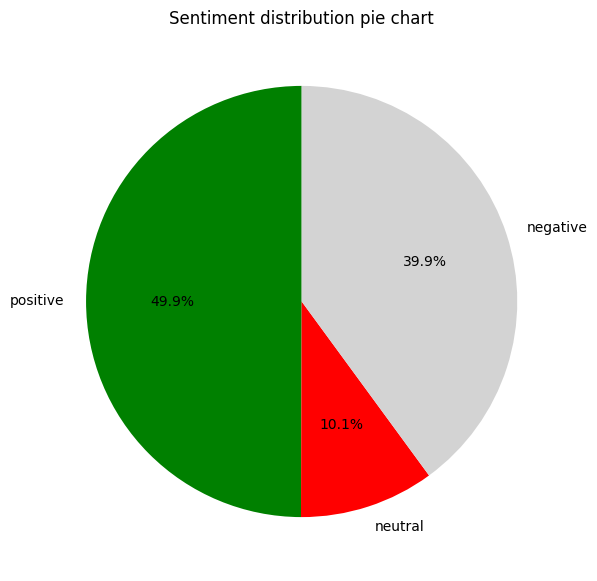

In [82]:
#步骤3: Language or contextual insight 语言或上下文洞察

#1.情感分布可视化,统计并绘制三种情感类别的数量，直观展示整体数据的情感倾向

# Sentiment distribution visualization: This method counts and plots
#the number of the three sentiment categories, visually displaying
#the overall sentiment trend of the data.

# 统计每种情感的计数
sentiment_counts = df_eval.groupBy("predicted_sentiment").count().toPandas()

plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts['count'], labels=sentiment_counts['predicted_sentiment'], autopct='%1.1f%%', startangle=90, colors=['green', 'red', 'lightgray'])
plt.title('Sentiment distribution pie chart')
plt.show()

In [83]:

#2.频繁正/负面词语（最有价值的洞察）
#分析 Positive 和 Negative 文本中出现频率最高的词语。这有助于了解用户具体对什么事物感到满意或不满。
#Analyze the most frequent words in positive and negative texts

#以 Positive 词汇为例
# 1. 过滤出正面文本
positive_df = df_eval.filter(col("predicted_sentiment") == "positive")

# 2. 对正面文本进行分词和计数
positive_words_df = positive_df.select(explode(col("cleaned_tokens")).alias("word"))
positive_word_counts = positive_words_df.groupBy("word").count().orderBy(col("count").desc())

print("\n--- Top 20 frequent positive words ---")
positive_word_counts.limit(20).show(truncate=False)

# 3. 对负面文本重复上述步骤
negative_df = df_eval.filter(col("predicted_sentiment") == "negative")
negative_words_df = negative_df.select(explode(col("cleaned_tokens")).alias("word"))
negative_word_counts = negative_words_df.groupBy("word").count().orderBy(col("count").desc())

print("\n--- Top 20 Frequent negative words ---")
negative_word_counts.limit(20).show(truncate=False)


--- Top 20 frequent positive words ---
+-------+-----+
|word   |count|
+-------+-----+
|com    |137  |
|twitter|85   |
|game   |85   |
|pic    |76   |
|co     |57   |
|like   |57   |
|love   |56   |
|http   |54   |
|best   |44   |
|good   |43   |
|get    |42   |
|play   |36   |
|amazon |34   |
|u      |33   |
|one    |32   |
|p      |31   |
|time   |31   |
|make   |30   |
|go     |27   |
|much   |26   |
+-------+-----+


--- Top 20 Frequent negative words ---
+----------+-----+
|word      |count|
+----------+-----+
|com       |104  |
|game      |72   |
|twitter   |60   |
|pic       |57   |
|dead      |38   |
|johnson   |36   |
|p         |36   |
|red       |36   |
|redemption|34   |
|co        |28   |
|http      |27   |
|shit      |26   |
|get       |26   |
|u         |24   |
|like      |23   |
|player    |22   |
|people    |22   |
|ban       |22   |
|k         |20   |
|fifa      |20   |
+----------+-----+



In [84]:
#task 4 Visualization and Insight Reporting

#步骤 1: 创建可视化图表，将继续使用 Python 的绘图库（Pandas、Matplotlib 和 Seaborn），并结合 wordcloud 库来完成可视化。
#1. 词云图 (Word Cloud)
#目的： 直观展示数据集中最常出现的词语，帮助快速识别关键话题。
#数据源： 使用 Task 2 中生成的最终清洗文本 (cleaned_text)。
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt


--- Word cloud generation ---


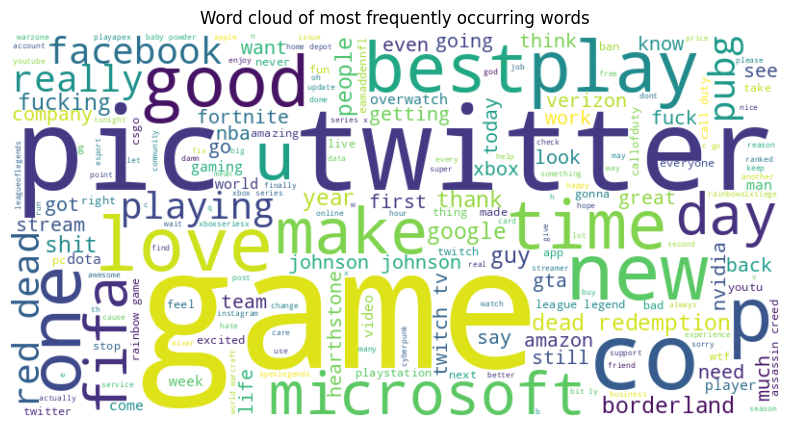

In [85]:
print("--- Word cloud generation ---")

# 1. 将所有清洗后的文本合并成一个长字符串
# 注意：PySpark toPandas() 可能会耗时，如果数据量大，可以先采样
all_text = " ".join(df_analysis.select("cleaned_text").toPandas()["cleaned_text"].astype(str))

# 2. 创建并生成词云图
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# 3. 显示生成的词云图
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word cloud of most frequently occurring words")
plt.show()


--- Sentiment distribution bar chart ---


/tmp/ipykernel_1369/2232655163.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='predicted_sentiment', y='count', data=sentiment_counts, palette=['green', 'red', 'gray'])


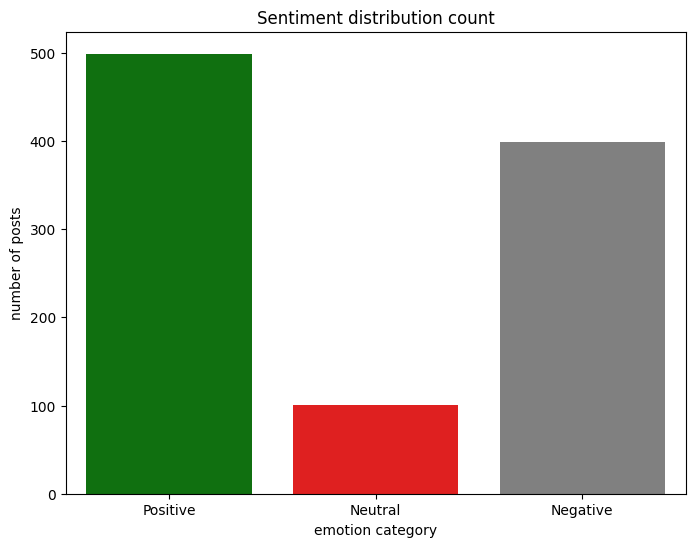

In [86]:
#2.情感分布条形图 (Bar Chart for Sentiment Distribution)
#目的： 清楚地展示数据集中积极、消极和中性情感的比例。
#数据源： 使用 Task 3 中生成的 predicted_sentiment 列。
print("\n--- Sentiment distribution bar chart ---")

# 1. 统计情感计数 (已在 Task 3 中执行，这里重新获取 Pandas DF)
sentiment_counts = df_analysis.groupBy("predicted_sentiment").count().toPandas()

# 2. 绘制条形图
plt.figure(figsize=(8, 6))
sns.barplot(x='predicted_sentiment', y='count', data=sentiment_counts, palette=['green', 'red', 'gray'])
plt.title('Sentiment distribution count')
plt.xlabel('emotion category')
plt.ylabel('number of posts')
plt.show()